# IRTF-SPEX Data Inspection

## This code is used to determine which images are viable for zonal wind field generation.

In [1]:
"""
Created on Thu Jan  2 13:57:20 2025

@author: ahyder
"""

# using planetmapper to plot some spex data

import planetmapper
from planetmapper.kernel_downloader import download_urls
import pylab as plt
import numpy as np
import math
from astropy.io import fits

In [2]:
# issued once. Already downloaded to ~/spice_kernels
# download_urls('https://naif.jpl.nasa.gov/pub/naif/generic_kernels/lsk/')
# print('lsk done...')
# download_urls('https://naif.jpl.nasa.gov/pub/naif/generic_kernels/pck/')
# print('pck done...')

# planetary ephemeris - needed once; already downloaded
# Locations of planetary system barycentres:
# download_urls('https://naif.jpl.nasa.gov/pub/naif/generic_kernels/spk/planets/de430.bsp')
# Locations of Jupiter and its major satellites:
# download_urls('https://naif.jpl.nasa.gov/pub/naif/generic_kernels/spk/satellites/jup365.bsp')


#  HST kernel - downloaded.
# download_urls('https://naif.jpl.nasa.gov/pub/naif/HST/kernels/spk/')

All appropriate kernels downloaded to ~/spice_kernels. Jupiter, major satellites, and HST information already stored...
jc055090.fits.gz <class 'str'>
2024-10-22 10:15:05.88281
332.981 <class 'float'>

jc277312.fits.gz <class 'str'>
2024-10-22 12:56:37.75781
360.848 <class 'float'>

jc451486.fits.gz <class 'str'>
2024-10-22 13:53:25.375
383.859 <class 'float'>

jc505516.fits.gz <class 'str'>
2024-10-22 14:01:56.875
256.776 <class 'float'>



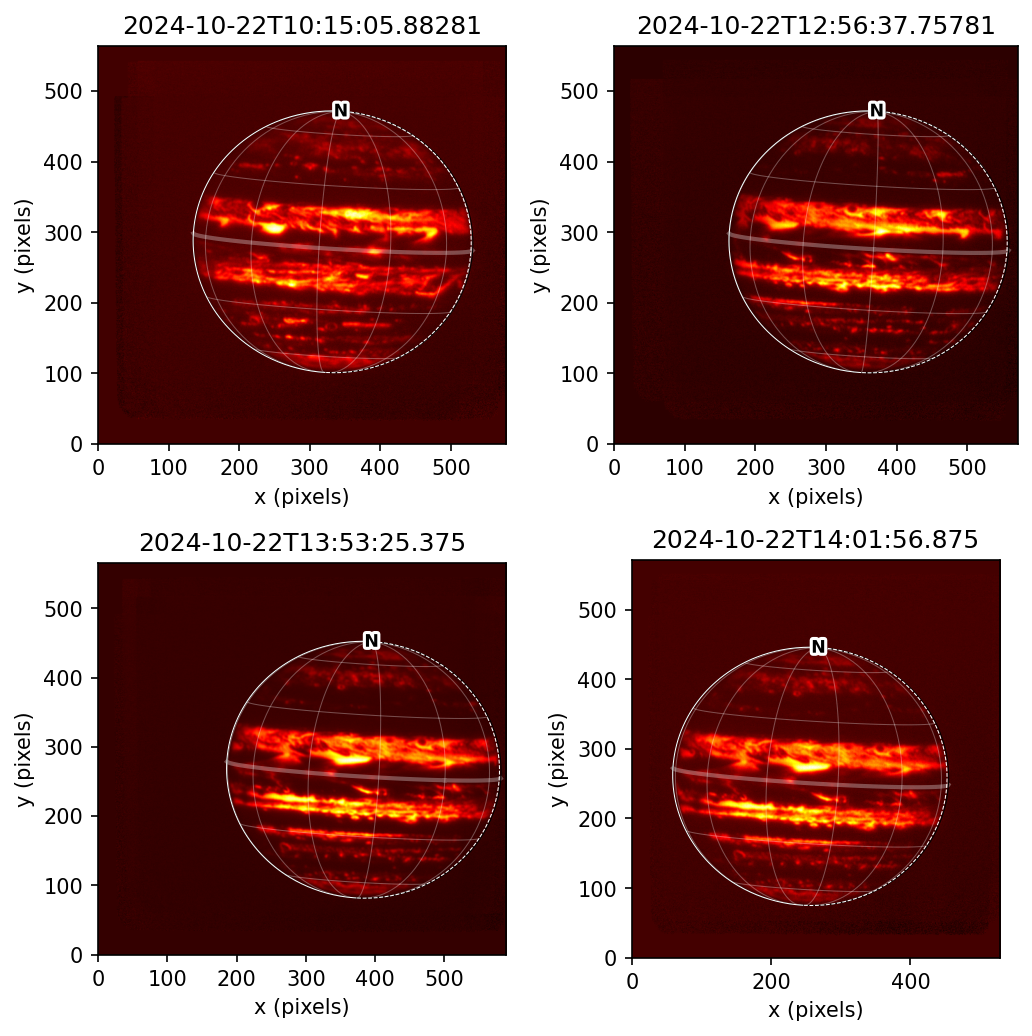

In [3]:
print('All appropriate kernels downloaded to ~/spice_kernels. Jupiter, major satellites, and HST information already stored...')

day_str = '2024oct22/'
file_list = ['jc055090.fits.gz', 'jc277312.fits.gz', 'jc451486.fits.gz', 'jc505516.fits.gz'] # for Oct. 22, 2024

day_str_oct23 = '2024oct23/'
file_list_oct23 = ['jc057087.fits.gz', 'jc701735.fits.gz', 'jc833859.fits.gz'] # for Oct. 23, 2024

# Number of images
num_images = len(file_list)
ncols = math.ceil(math.sqrt(num_images))
nrows = math.ceil(num_images / ncols)

fig1, axs1 = plt.subplots(
nrows=nrows, ncols=ncols, figsize=(7, 7), dpi=150)
axs1 = axs1.flatten()

date_meta_list = []

for ax1, f in zip(axs1, file_list):
    print(f, type(f))
    
    hdul = fits.open('spex/' + day_str + f)
    hdr = hdul[0].header
    print(hdr['DATE_OBS'], hdr['TIME_OBS'])
    utc_str = hdr['DATE_OBS'] + 'T' + hdr['TIME_OBS']

    date_meta_list.append(hdr['TIME_OBS'])

    disc_x, disc_y = hdr['CX'], hdr['CY'] # obtained automatically so the disc will be around the correct point
    print(disc_x, type(disc_x))
    print()


    # navigational data made using the GUI - doing it here results in the NASA IRTF being set as observer.
    # Any spice available for it though? Would make things easier!
    observation = planetmapper.Observation('spex/' + day_str + f, 
                                           target='jupiter', 
                                           utc=utc_str, 
                                           observer='EARTH')
    
    # body = planetmapper.Body('jupiter', utc_str, observer='EARTH')
    # body = planetmapper.BodyXY('jupiter', utc_str, observer='EARTH')
    # body.plot_wireframe_radec(show=False)
    # body.set_disc_params(x0=disc_x, y0=disc_y)

    # Run the GUI to fit the disc interactively
    #observation.run_gui() # good for fitting the disc directly
    disc_r0 = 198.25


    # plt.figure(dpi=150)
    # observation.plot_backplane_img('LON-GRAPHIC')
    # plt.show()
    
    

    ax1.imshow(observation.data[0, ...], origin='lower', cmap='hot')
    observation.set_disc_params(x0=disc_x, y0=disc_y, r0=disc_r0)
    observation.plot_wireframe_xy(ax1, formatting={
                                      'grid': {'linestyle': '-', 'linewidth': 0.5, 'alpha': 0.3, 'color':'w'},
                                      'prime_meridian': {'linewidth': 1, 'color': 'r'},
                                      'terminator': {'linewidth': 0.5, 'color':'w'},
                                      'equator': {'linewidth': 2, 'color':'w'},
                                      'limb_illuminated': {'linewidth': 0.5, 'color':'w'},},
                                    indicate_equator=True,
                                )
    # ax1.set_title(hdr['TIME_OBS']+'UTC')
    ax1.set_title(utc_str)
    # plt.show()
fig1.tight_layout()


plt.show()


2024-10-22 10:15:05.88281
2024-10-22 12:56:37.75781
2024-10-22 13:53:25.375
2024-10-22 14:01:56.875


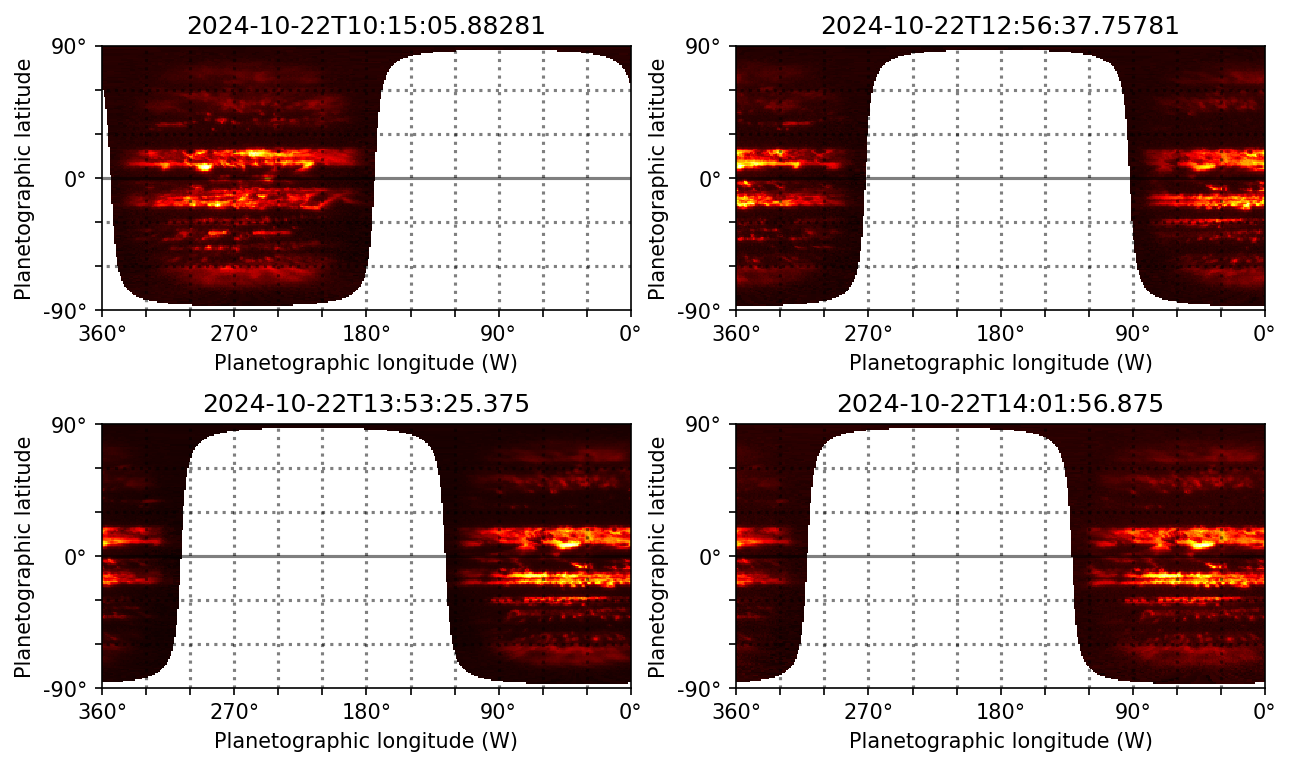

In [4]:
fig2, axs2 = plt.subplots(
nrows=nrows, ncols=ncols, figsize=(10, 6), dpi=150)
axs2 = axs2.flatten()

for ax2, f in zip(axs2, file_list):
    
    hdul = fits.open('spex/' + day_str + f)
    hdr = hdul[0].header
    print(hdr['DATE_OBS'], hdr['TIME_OBS'])
    utc_str = hdr['DATE_OBS'] + 'T' + hdr['TIME_OBS']
    disc_x, disc_y = hdr['CX'], hdr['CY']
    
    observation = planetmapper.Observation('spex/' + day_str + f, 
                                            target='jupiter', 
                                            utc=utc_str, 
                                            observer='EARTH')
    observation.set_disc_params(x0=disc_x, y0=disc_y, r0=disc_r0)
    
    # Plot a mapped RGB image of the data in the top right
    degree_interval = 1.0  # Plot maps with 4 pixels/degree
    emission_cutoff = 80

    mapped_data = observation.get_mapped_data('nearest')  # get the mapped data
    
    # Display mapped image and add a useful annotation
    observation.imshow_map(mapped_data[0, ...], ax2, cmap='hot')
    ax2.set_title(utc_str)
    # plt.figure(dpi=125)
    # ax2.contourf(np.linspace(360,0,360), np.linspace(-90,90,180), mapped_data[0, ...], 256, cmap='magma')
    # ax2.invert_xaxis()
    # plt.grid(True, 'both', ls=':')
    # ax2.title('Day and Time: ' + '\n' + hdr['DATE_OBS'] + ' ' + hdr['TIME_OBS'] + ' UTC')
    # ax2.set_xlabel('Planetographic longitude (W)'), plt.ylabel('Planetographic latitude')

# fig2.tight_layout()

plt.show()

2024-10-22 10:15:05.88281
2024-10-22 12:56:37.75781
2024-10-22 13:53:25.375
2024-10-22 14:01:56.875


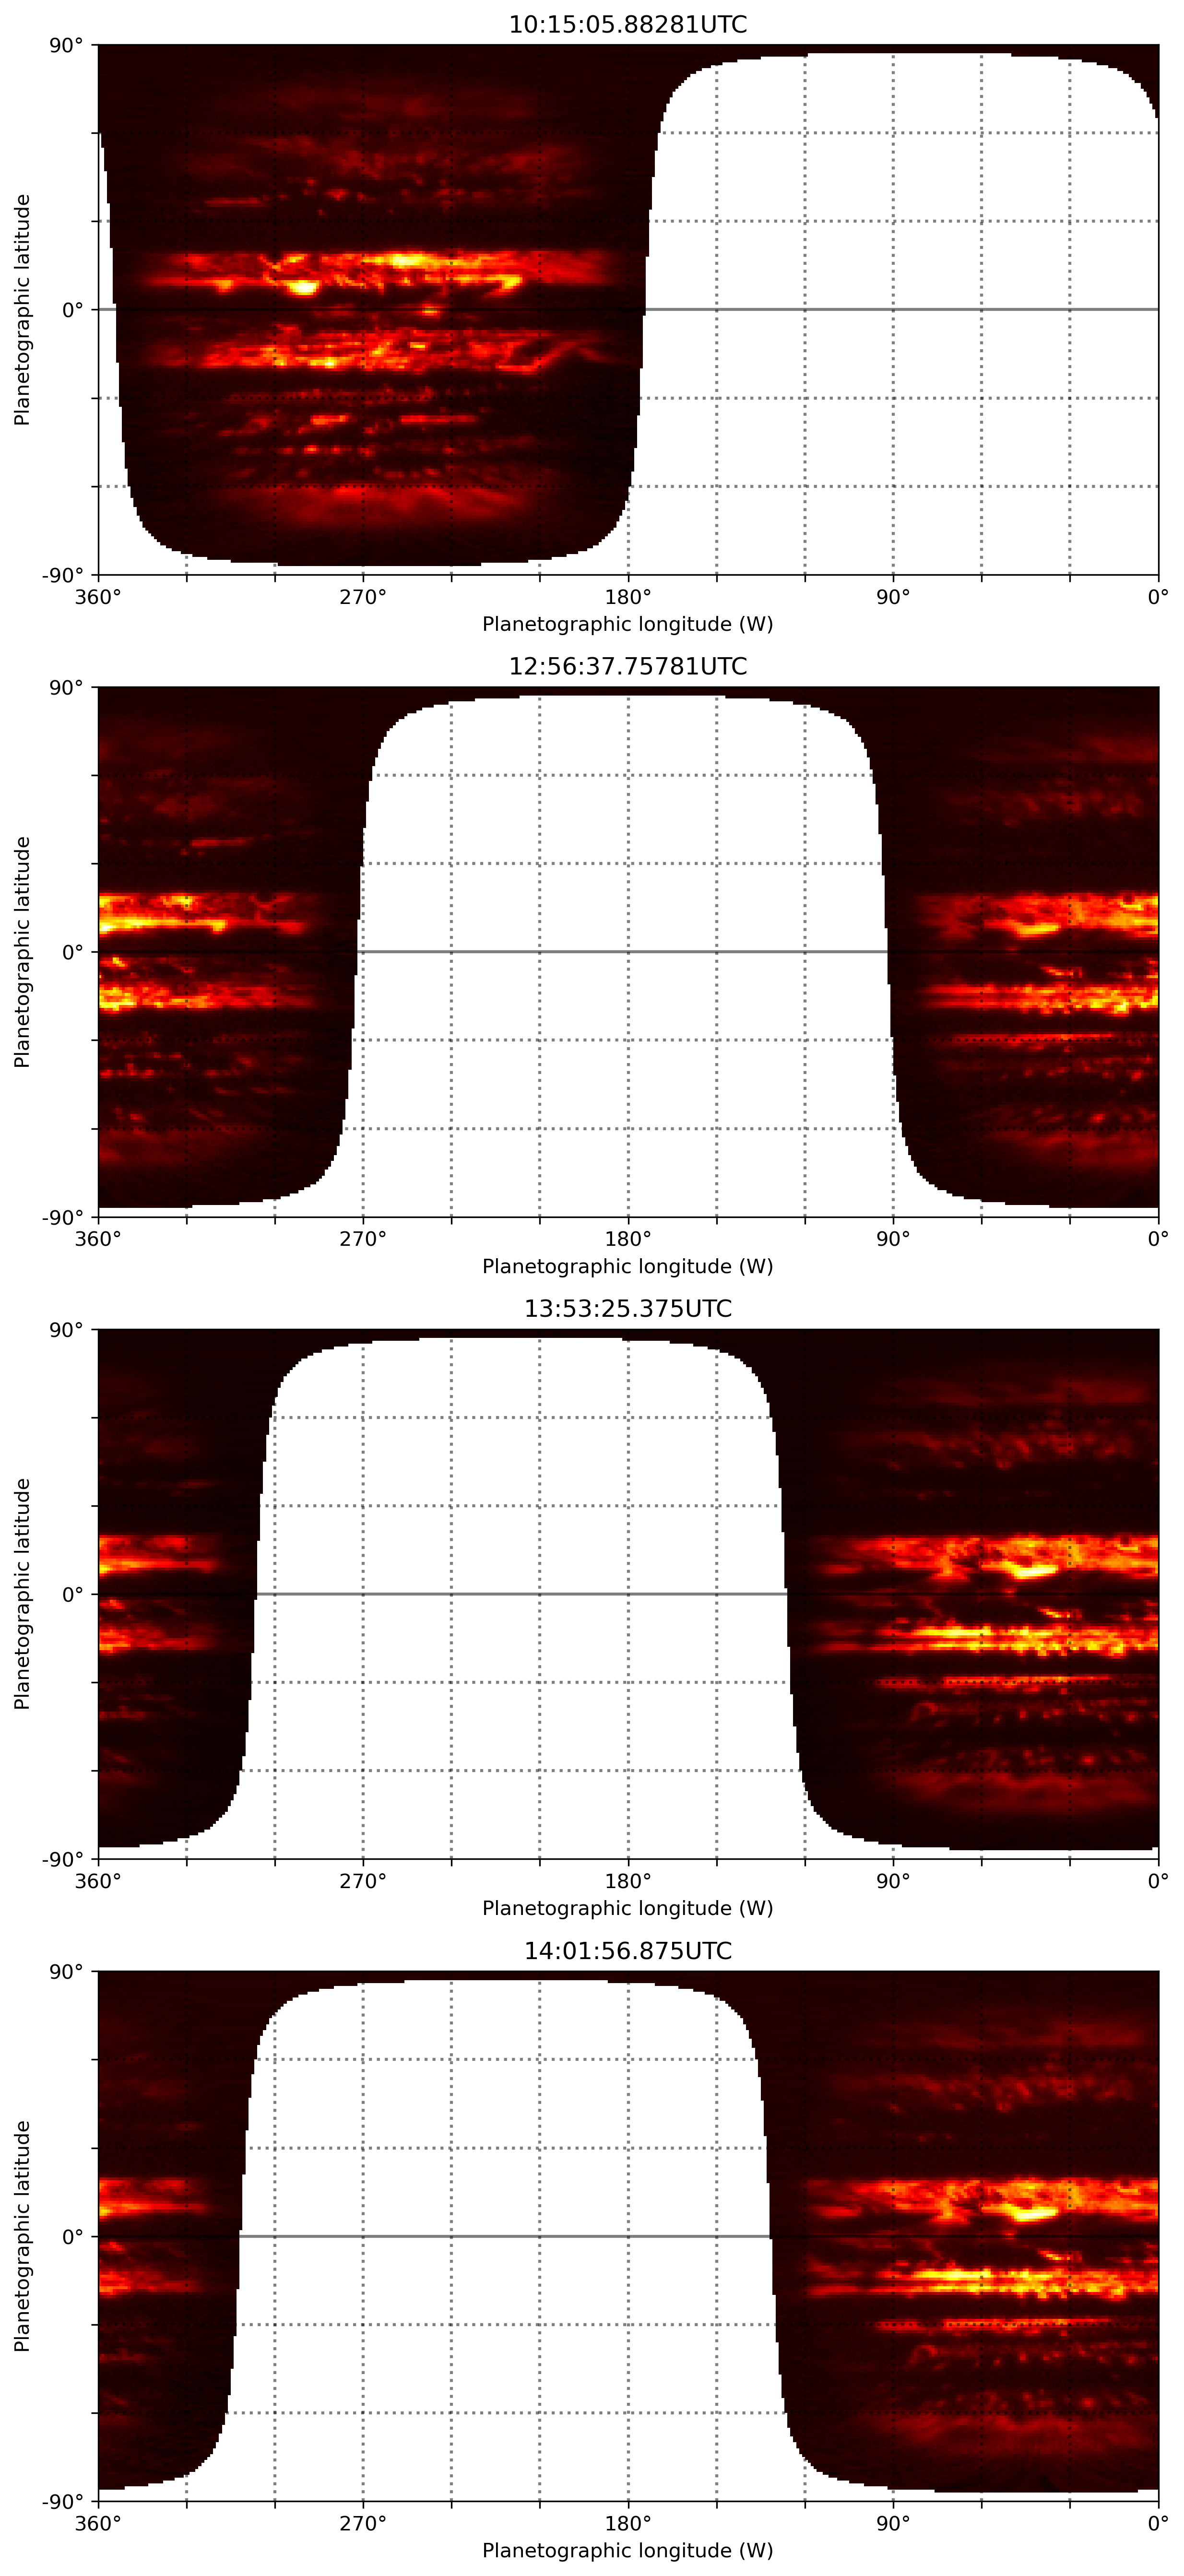

In [5]:
# plt.figure(figsize=(8,4), dpi=200)
# plt.contourf(np.linspace(360,0,360), np.linspace(-90,90,180), mapped_data[0, ...], 256, origin='lower', cmap='inferno')
# plt.hlines(18, 0, 360, color='c', ls=':')
# plt.hlines(8, 0, 360, color='c', ls=':')
# plt.gca().invert_xaxis()
# plt.grid(True, 'both', ls=':')

fig2, axs2 = plt.subplots(
nrows=4, ncols=1, figsize=(12, 18), dpi=300)
axs2 = axs2.flatten()

cmap_meta_list = []
obs_meta_list = []

for ax2, f in zip(axs2, file_list):
    
    hdul = fits.open('spex/' + day_str + f)
    hdr = hdul[0].header
    print(hdr['DATE_OBS'], hdr['TIME_OBS'])
    utc_str = hdr['DATE_OBS'] + 'T' + hdr['TIME_OBS']
    disc_x, disc_y = hdr['CX'], hdr['CY']
    
    observation = planetmapper.Observation('spex/' + day_str + f, 
                                            target='jupiter', 
                                            utc=utc_str, 
                                            observer='EARTH')
    observation.set_disc_params(x0=disc_x, y0=disc_y, r0=disc_r0)   
    obs_meta_list.append(observation)
    
    # Plot a mapped RGB image of the data in the top right
    degree_interval = 1.0  # Plot maps with 4 pixels/degree
    emission_cutoff = 80

    mapped_data = observation.get_mapped_data('linear')  # get the mapped data
    cmap_meta_list.append(mapped_data)
    
    # Display mapped image and add a useful annotation
    observation.imshow_map(mapped_data[0, ...], ax2, cmap='hot')
    ax2.set_title(hdr['TIME_OBS']+'UTC')
    # plt.figure(dpi=125)
    # ax2.contourf(np.linspace(360,0,360), np.linspace(-90,90,180), mapped_data[0, ...], 256, cmap='magma')
    # ax2.invert_xaxis()
    # plt.grid(True, 'both', ls=':')
    # ax2.title('Day and Time: ' + '\n' + hdr['DATE_OBS'] + ' ' + hdr['TIME_OBS'] + ' UTC')
    # ax2.set_xlabel('Planetographic longitude (W)'), plt.ylabel('Planetographic latitude')

fig2.tight_layout()

plt.show()

(Text(0.5, 0, 'Planetographic Longitude (W)'), Text(0, 0.5, 'Pixel value'))

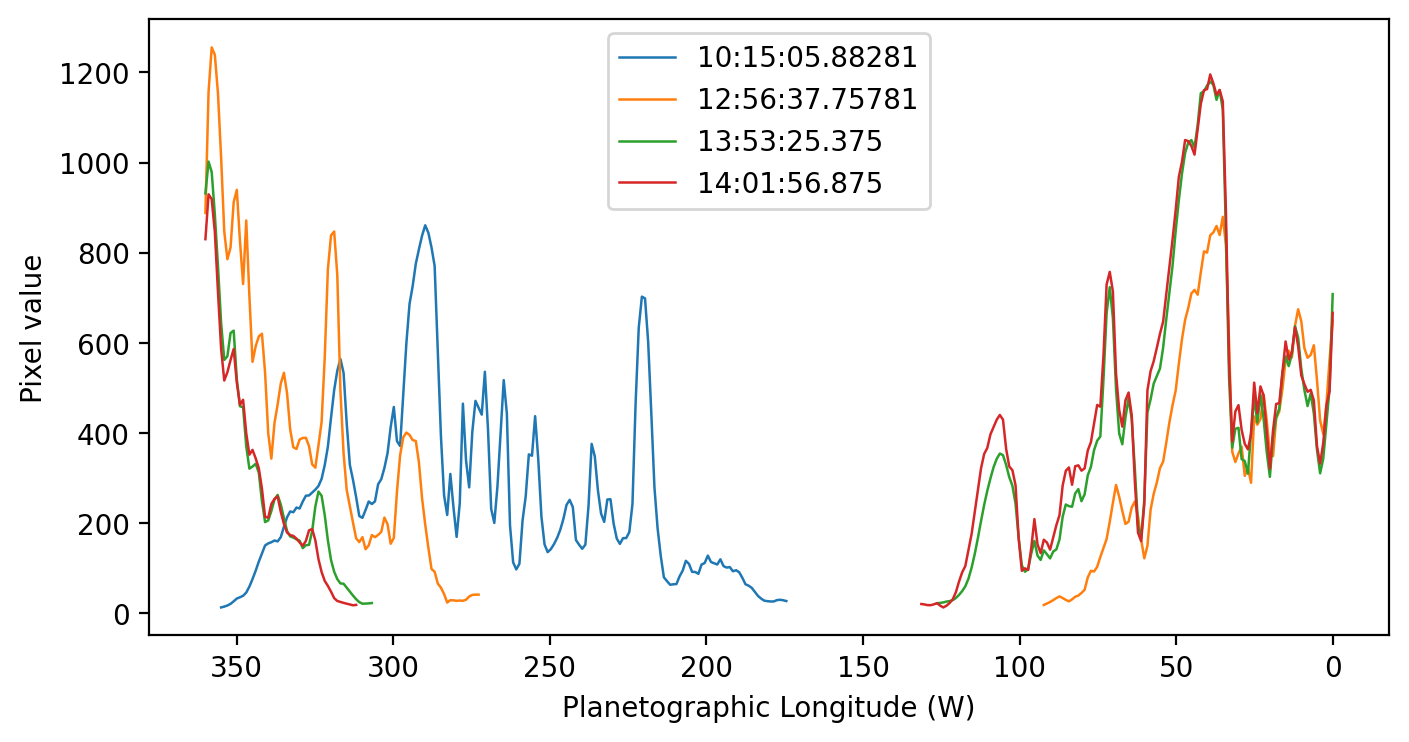

In [6]:
plt.figure(figsize=(8,4), dpi=200)
# plt.plot(np.linspace(360,0,360), cmap_meta_list[0][0, 90 + 18], lw=0.75)
for i in range(4):
    plt.plot(np.linspace(360,0,360), cmap_meta_list[i][0, 90 + 8], lw=0.9, label=date_meta_list[i])
plt.gca().invert_xaxis()
plt.legend()
plt.xlabel('Planetographic Longitude (W)'), plt.ylabel('Pixel value')

In [7]:
mapped_data.shape, obs_meta_list[3]

((1, 180, 360),
 Observation('spex/2024oct22/jc505516.fits.gz', target='JUPITER', utc='2024-10-22T14:01:56.875000'))

In [8]:
def makeFullMap(cmap_object_list):
    '''
    Make al pixels positive using localized averaging.
    Some pixel values are negative due to the sky subtraction.
    '''
    full_map = np.full((180, 360), np.nan)
    weights = np.zeros((180, 360))

    for image in cmap_object_list:
        pixel_data = image[0, :, :]  # Extract pixel data
    
        for lat in range(180):
            for lon in range(360):
                if not np.isnan(pixel_data[lat, lon]):  # Skip missing data
                    if np.isnan(full_map[lat, lon]):
                        full_map[lat, lon] = pixel_data[lat, lon]
                        weights[lat, lon] = 1
                    else:
                        full_map[lat, lon] += pixel_data[lat, lon]
                        weights[lat, lon] += 1

    full_map /= weights  # Normalize by the number of contributions so overlaps are handled. Some values will still be negative for now.
    return full_map
                    


In [9]:
full_map_Oct_22 = makeFullMap(cmap_meta_list)

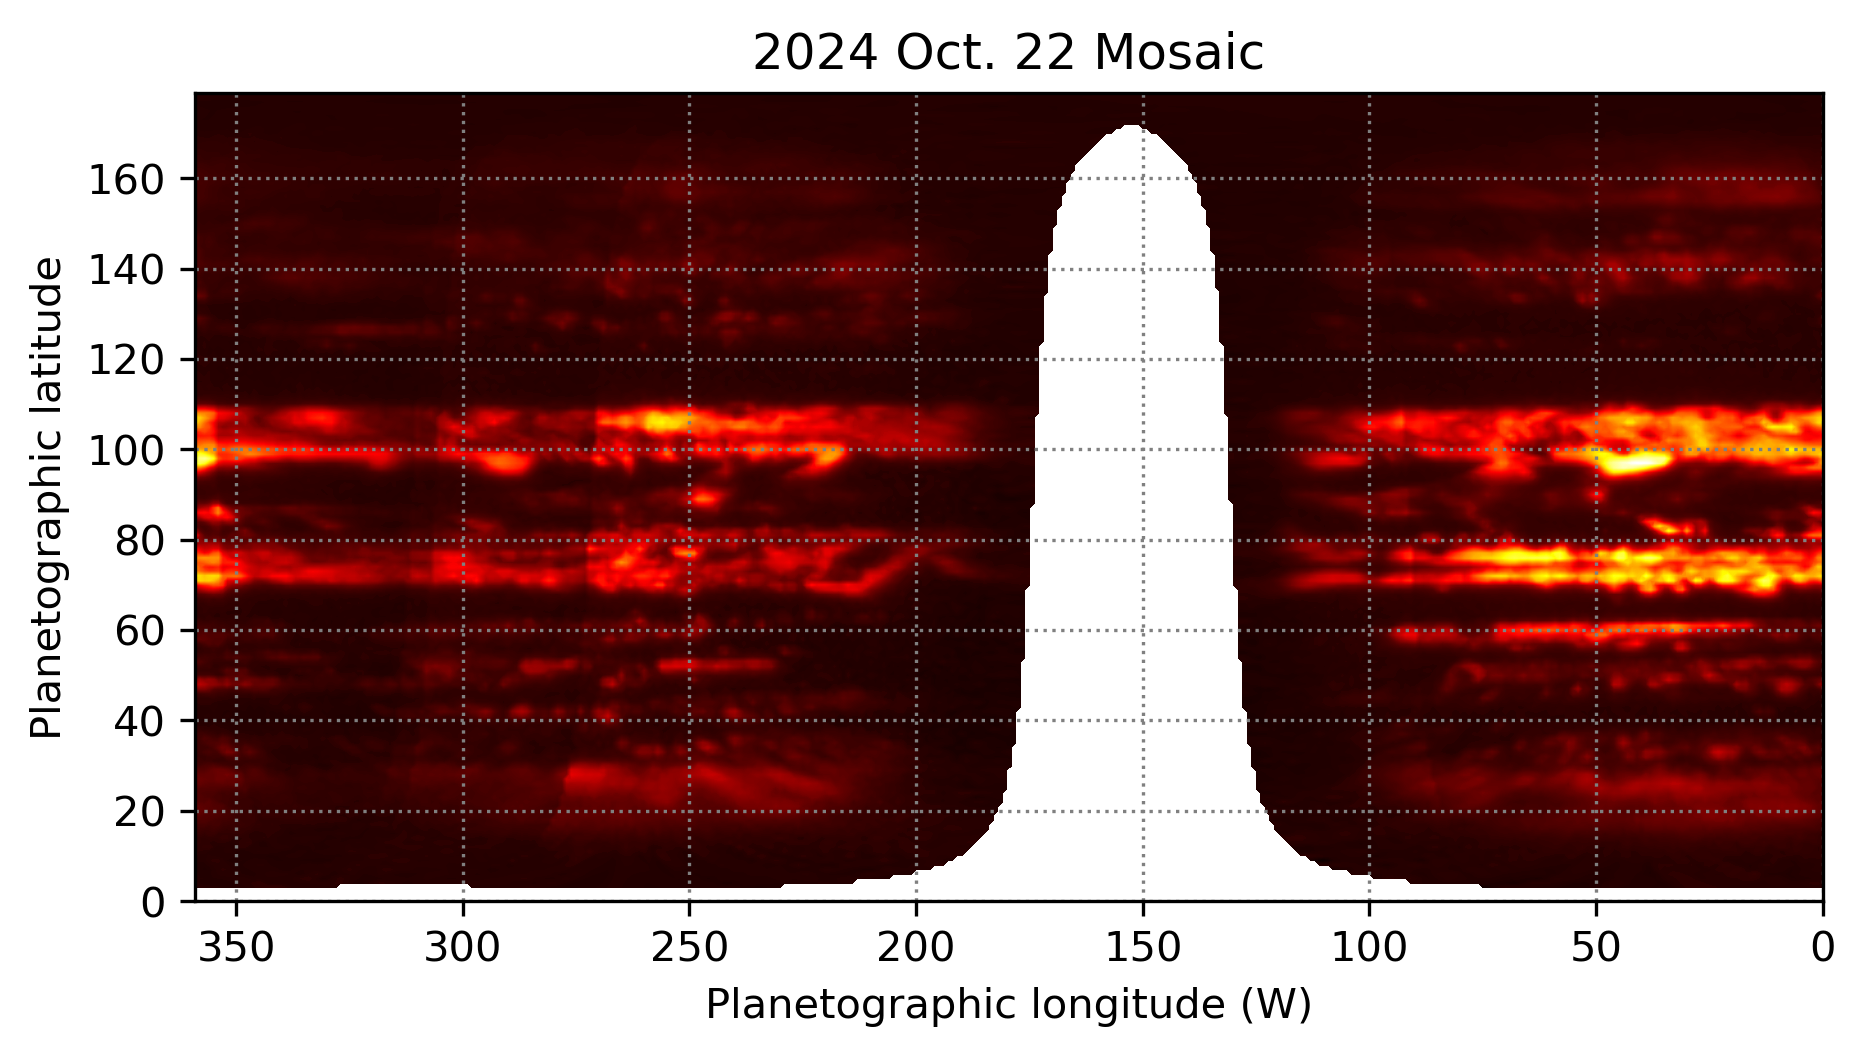

In [17]:
plt.figure(figsize=(7,3.5), dpi=300)
# plt.imshow(full_map_Oct_22[:, ::-1], origin='lower', interpolation='spline36', cmap='gist_heat')
plt.contourf(range(360), range(180), full_map_Oct_22[:, ::-1], 256, cmap='hot') # longitudes must be reversed.
plt.gca().invert_xaxis() # inverted for consistency with previous maps
plt.xlabel('Planetographic longitude (W)'), plt.ylabel('Planetographic latitude')
plt.title('2024 Oct. 22 Mosaic')
plt.grid(True, 'both', ls=':', c='gray')

2024-10-23 10:33:15.97266
2024-10-23 14:26:47.72266
2024-10-23 15:04:59.125


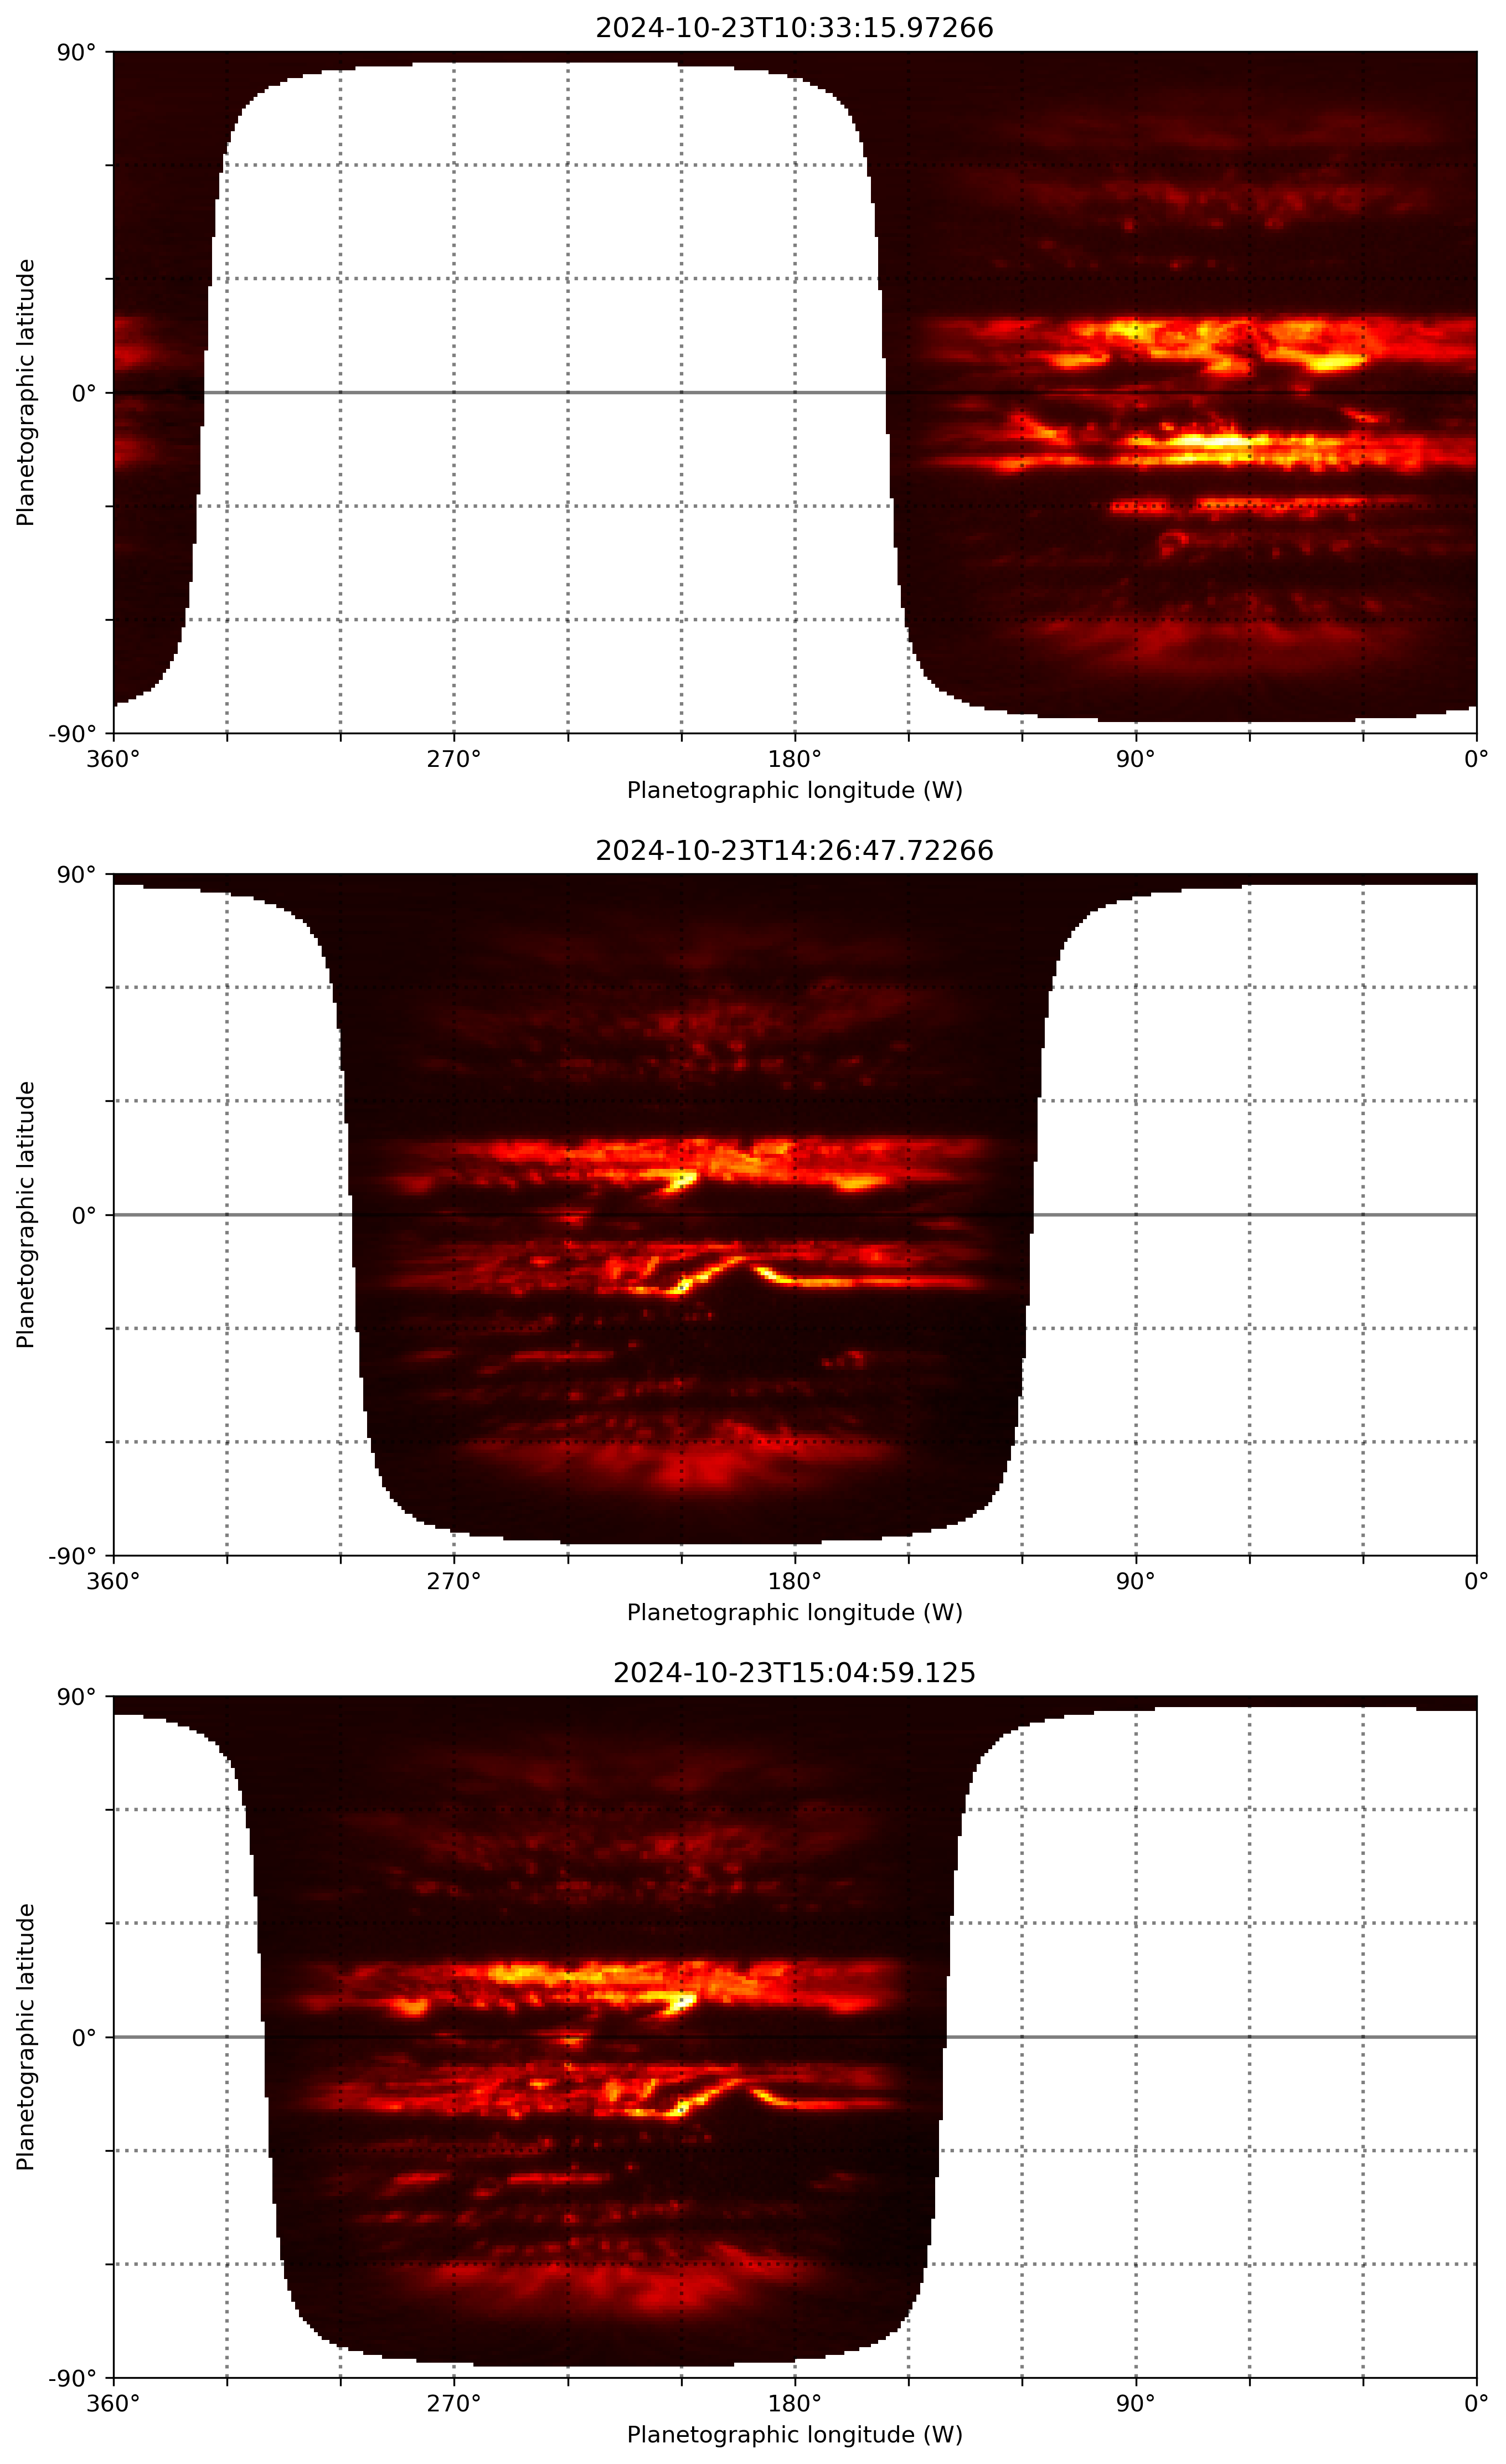

In [18]:

fig3, axs3 = plt.subplots(
nrows=3, ncols=1, figsize=(9, 15), dpi=300)
axs3 = axs3.flatten()

cmap_meta_list = []
obs_meta_list = []

day_str = day_str_oct23
file_list = file_list_oct23

# %matplotlib inline

for ax3, f in zip(axs3, file_list):
    
    hdul = fits.open('spex/' + day_str + f)
    hdr = hdul[0].header
    print(hdr['DATE_OBS'], hdr['TIME_OBS'])
    utc_str = hdr['DATE_OBS'] + 'T' + hdr['TIME_OBS']
    disc_x, disc_y = hdr['CX'], hdr['CY']
    
    observation = planetmapper.Observation('spex/' + day_str + f, 
                                            target='jupiter', 
                                            utc=utc_str, 
                                            observer='EARTH')
    observation.set_disc_params(x0=disc_x, y0=disc_y, r0=disc_r0)   
    obs_meta_list.append(observation)

    mapped_data = observation.get_mapped_data('linear')  # get the mapped data
    cmap_meta_list.append(mapped_data)
    
    # Display mapped image and add a useful annotation
    observation.imshow_map(mapped_data[0, ...], ax3, cmap='hot')
    # ax3.set_title(hdr['TIME_OBS']+'UTC')
    ax3.set_title(utc_str)

fig3.tight_layout()

plt.show()